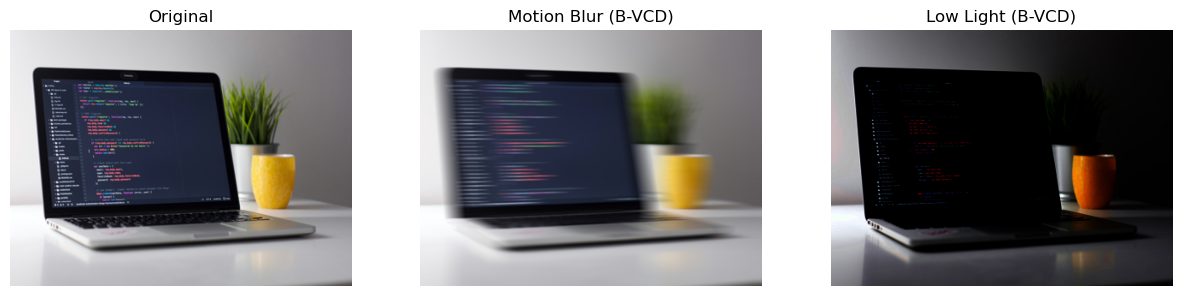

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 1. 테스트용 이미지 불러오기 (임의의 샘플 이미지)
url = "https://images.unsplash.com/photo-1517694712202-14dd9538aa97"
response = requests.get(url)
original_img = Image.open(BytesIO(response.content)).resize((400, 300))

# 2. Motion Blur (물리적 흔들림) 함수
def apply_motion_blur(image, kernel_size=15):
    img_array = np.array(image)
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel /= kernel_size
    blurred = cv2.filter2D(img_array, -1, kernel)
    return Image.fromarray(blurred)

# 3. Low-Light (조도 부족) 함수
def apply_low_light(image, gamma=0.3):
    img_array = np.array(image)
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    darkened = cv2.LUT(img_array, table)
    return Image.fromarray(darkened)

# 변환 적용
blurred_img = apply_motion_blur(original_img, kernel_size=25)
darkened_img = apply_low_light(original_img, gamma=0.2)

# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_img); axes[0].set_title("Original")
axes[1].imshow(blurred_img); axes[1].set_title("Motion Blur (B-VCD)")
axes[2].imshow(darkened_img); axes[2].set_title("Low Light (B-VCD)")
for ax in axes: ax.axis('off')
plt.show()